### 5. WAP to train and evaluate a convolutional neural network using Keras Library to classify MNIST fashion dataset. Demonstrate the effect of filter size, regularization, batch size and optimization algorithm on model performance.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

In [4]:
# Reshape data for CNN input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [5]:
# Function to create a CNN model with varying hyperparameters
def create_model(filter_size=3, reg_factor=0.001, optimizer='adam'):
    model = keras.Sequential([
        layers.Conv2D(32, (filter_size, filter_size), activation='relu', kernel_regularizer=regularizers.l2(reg_factor), input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (filter_size, filter_size), activation='relu', kernel_regularizer=regularizers.l2(reg_factor)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(reg_factor)),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [6]:
# Define hyperparameters
filter_sizes = [3, 5]
regularization_factors = [0.001, 0.0001]
batch_sizes = [32, 64]
optimizers = ['adam', 'sgd']

Training model with filter_size=3, reg_factor=0.001, batch_size=32, optimizer=adam


c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7753 - loss: 0.7820 - val_accuracy: 0.8455 - val_loss: 0.5266
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8675 - loss: 0.4674 - val_accuracy: 0.8731 - val_loss: 0.4504
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8801 - loss: 0.4254 - val_accuracy: 0.8667 - val_loss: 0.4702
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8878 - loss: 0.4017 - val_accuracy: 0.8346 - val_loss: 0.5424
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8932 - loss: 0.3882 - val_accuracy: 0.8849 - val_loss: 0.4119
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8974 - loss: 0.3767 - val_accuracy: 0.8912 - val_loss: 0.4032
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8991 - loss: 0.3688 - val_accuracy: 0.8882 - val_loss: 0.3929
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9008 - loss: 0

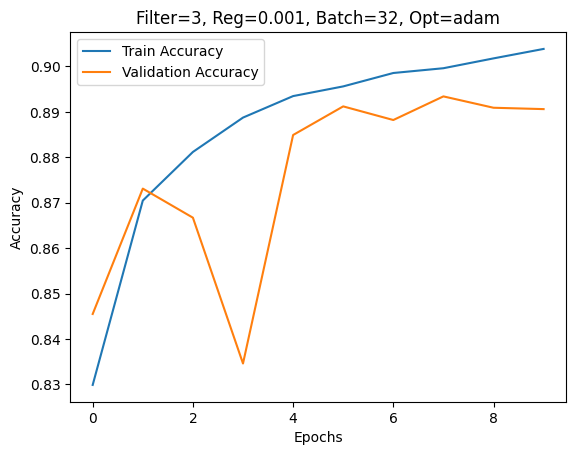

Training model with filter_size=3, reg_factor=0.001, batch_size=32, optimizer=sgd
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5727 - loss: 1.5331 - val_accuracy: 0.7634 - val_loss: 0.9153
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7828 - loss: 0.8498 - val_accuracy: 0.7982 - val_loss: 0.8173
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8248 - loss: 0.7362 - val_accuracy: 0.8349 - val_loss: 0.7085
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8458 - loss: 0.6723 - val_accuracy: 0.8321 - val_loss: 0.6923
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8570 - loss: 0.6322 - val_accuracy: 0.8624 - val_loss: 0.6183
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8643 - loss: 0.5990 - val_accuracy: 0.8613 - val_loss: 0.6026
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8731 - loss: 0.5692 - val_accuracy: 0.8704 - val_loss: 0.5676
E

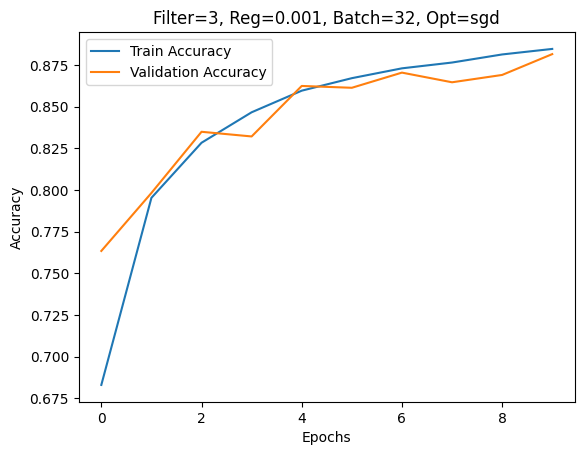

Training model with filter_size=3, reg_factor=0.001, batch_size=64, optimizer=adam
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7556 - loss: 0.8710 - val_accuracy: 0.8581 - val_loss: 0.5109
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8663 - loss: 0.4818 - val_accuracy: 0.8716 - val_loss: 0.4620
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8764 - loss: 0.4377 - val_accuracy: 0.8686 - val_loss: 0.4600
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8865 - loss: 0.4116 - val_accuracy: 0.8801 - val_loss: 0.4310
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8908 - loss: 0.3953 - val_accuracy: 0.8905 - val_loss: 0.3990
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8952 - loss: 0.3805 - val_accuracy: 0.8925 - val_loss: 0.3957
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8979 - loss: 0.3730 - val_accuracy: 0.8907 - val_loss: 0.3940
Epoch 8

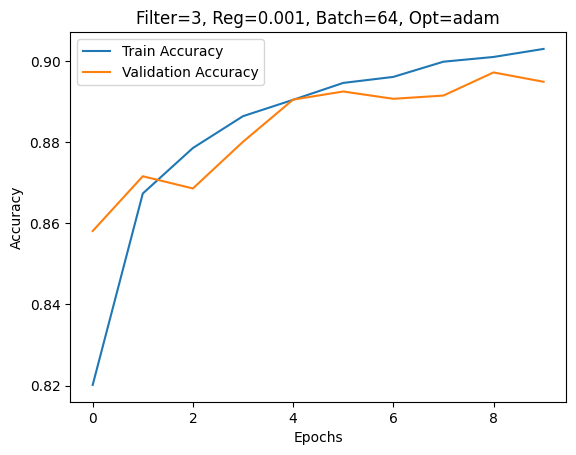

Training model with filter_size=3, reg_factor=0.001, batch_size=64, optimizer=sgd
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.5019 - loss: 1.7991 - val_accuracy: 0.7433 - val_loss: 1.0053
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7518 - loss: 0.9464 - val_accuracy: 0.7729 - val_loss: 0.8698
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7909 - loss: 0.8314 - val_accuracy: 0.7673 - val_loss: 0.8556
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8118 - loss: 0.7753 - val_accuracy: 0.7905 - val_loss: 0.8181
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8263 - loss: 0.7330 - val_accuracy: 0.8133 - val_loss: 0.7487
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8387 - loss: 0.6974 - val_accuracy: 0.8377 - val_loss: 0.6950
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8460 - loss: 0.6736 - val_accuracy: 0.8173 - val_loss: 0.7216
Epoch 8/10
938

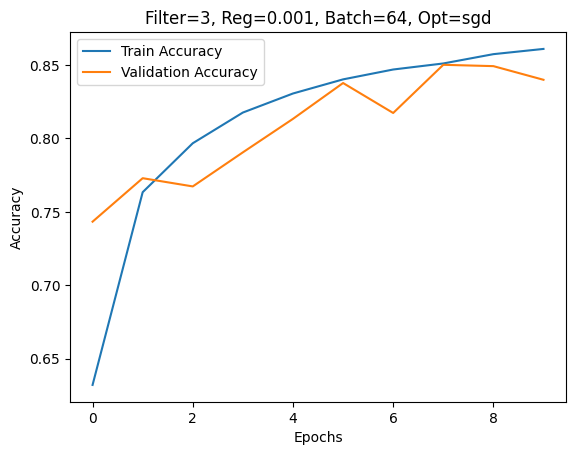

Training model with filter_size=3, reg_factor=0.0001, batch_size=32, optimizer=adam
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7833 - loss: 0.6390 - val_accuracy: 0.8736 - val_loss: 0.3830
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8868 - loss: 0.3476 - val_accuracy: 0.8839 - val_loss: 0.3632
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9012 - loss: 0.3099 - val_accuracy: 0.8723 - val_loss: 0.3857
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9096 - loss: 0.2915 - val_accuracy: 0.8928 - val_loss: 0.3378
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9176 - loss: 0.2733 - val_accuracy: 0.9053 - val_loss: 0.3222
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9219 - loss: 0.2618 - val_accuracy: 0.9004 - val_loss: 0.3221
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9303 - loss: 0.2460 - val_accuracy: 0.9052 - val_loss: 0.3151

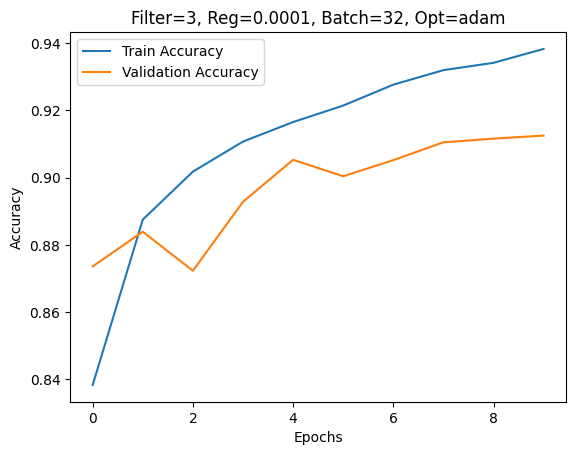

Training model with filter_size=3, reg_factor=0.0001, batch_size=32, optimizer=sgd
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5671 - loss: 1.2721 - val_accuracy: 0.7712 - val_loss: 0.6677
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7880 - loss: 0.5951 - val_accuracy: 0.8201 - val_loss: 0.5322
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8229 - loss: 0.5093 - val_accuracy: 0.8349 - val_loss: 0.4861
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8426 - loss: 0.4623 - val_accuracy: 0.8415 - val_loss: 0.4697
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8505 - loss: 0.4361 - val_accuracy: 0.8562 - val_loss: 0.4315
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8636 - loss: 0.4040 - val_accuracy: 0.8586 - val_loss: 0.4163
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8690 - loss: 0.3922 - val_accuracy: 0.8597 - val_loss: 0.4193


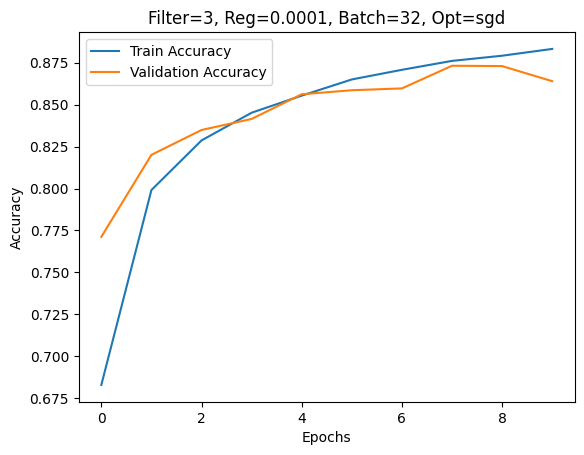

Training model with filter_size=3, reg_factor=0.0001, batch_size=64, optimizer=adam
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7536 - loss: 0.7065 - val_accuracy: 0.8639 - val_loss: 0.4200
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8784 - loss: 0.3705 - val_accuracy: 0.8776 - val_loss: 0.3844
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8929 - loss: 0.3307 - val_accuracy: 0.8885 - val_loss: 0.3511
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9057 - loss: 0.2981 - val_accuracy: 0.8912 - val_loss: 0.3425
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9140 - loss: 0.2799 - val_accuracy: 0.8986 - val_loss: 0.3315
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9207 - loss: 0.2641 - val_accuracy: 0.9034 - val_loss: 0.3093
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9258 - loss: 0.2536 - val_accuracy: 0.9044 - val_loss: 0.3103
Epoch 8/1

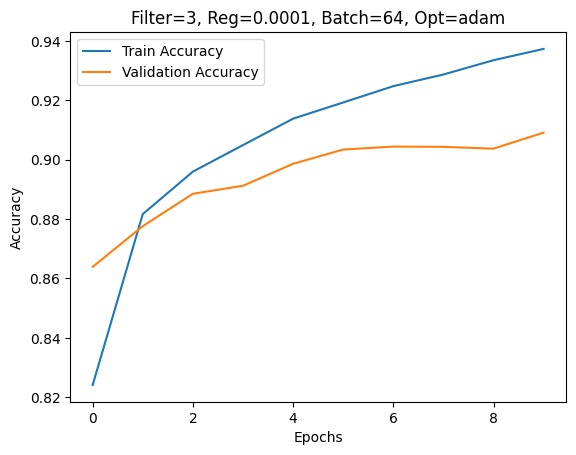

Training model with filter_size=3, reg_factor=0.0001, batch_size=64, optimizer=sgd
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4837 - loss: 1.6020 - val_accuracy: 0.6526 - val_loss: 0.9020
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7372 - loss: 0.7249 - val_accuracy: 0.7556 - val_loss: 0.6654
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7812 - loss: 0.6090 - val_accuracy: 0.7115 - val_loss: 0.6864
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8102 - loss: 0.5396 - val_accuracy: 0.8203 - val_loss: 0.5300
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8278 - loss: 0.4998 - val_accuracy: 0.7999 - val_loss: 0.5452
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8414 - loss: 0.4686 - val_accuracy: 0.8097 - val_loss: 0.5214
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8474 - loss: 0.4484 - val_accuracy: 0.8380 - val_loss: 0.4716
Epoch 8/10
9

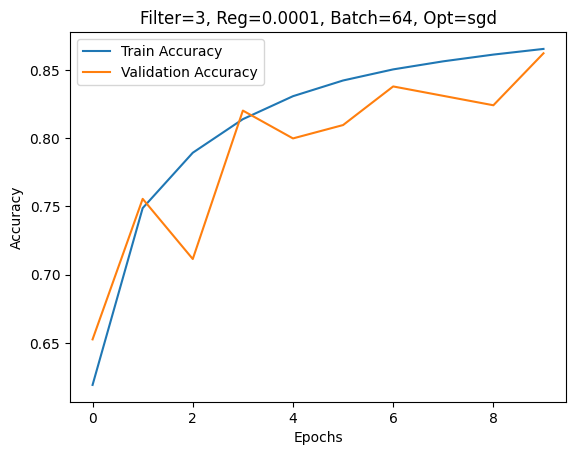

Training model with filter_size=5, reg_factor=0.001, batch_size=32, optimizer=adam
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7616 - loss: 0.8098 - val_accuracy: 0.8587 - val_loss: 0.5005
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8705 - loss: 0.4646 - val_accuracy: 0.8733 - val_loss: 0.4466
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8866 - loss: 0.4127 - val_accuracy: 0.8789 - val_loss: 0.4290
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8945 - loss: 0.3896 - val_accuracy: 0.8804 - val_loss: 0.4224
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8956 - loss: 0.3800 - val_accuracy: 0.8902 - val_loss: 0.3988
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9010 - loss: 0.3665 - val_accuracy: 0.8949 - val_loss: 0.3812
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9011 - loss: 0.3582 - val_accuracy: 0.8939 - val_loss: 0.3846


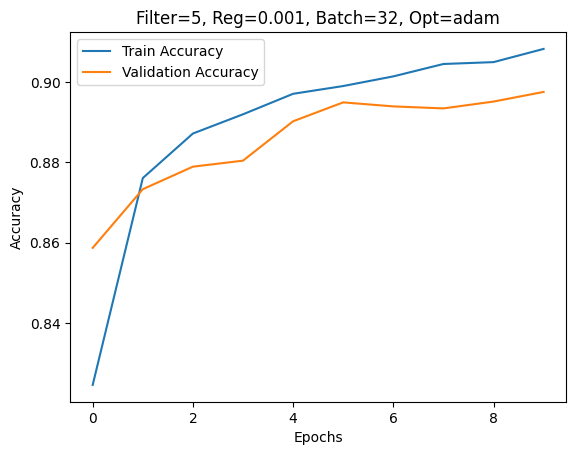

Training model with filter_size=5, reg_factor=0.001, batch_size=32, optimizer=sgd
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5730 - loss: 1.4597 - val_accuracy: 0.7228 - val_loss: 0.9951
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7935 - loss: 0.8222 - val_accuracy: 0.8171 - val_loss: 0.7600
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8289 - loss: 0.7188 - val_accuracy: 0.8204 - val_loss: 0.7231
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8485 - loss: 0.6647 - val_accuracy: 0.8547 - val_loss: 0.6431
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8604 - loss: 0.6140 - val_accuracy: 0.8584 - val_loss: 0.6145
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8666 - loss: 0.5809 - val_accuracy: 0.8624 - val_loss: 0.5916
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8712 - loss: 0.5559 - val_accuracy: 0.8682 - val_loss: 0.5609
E

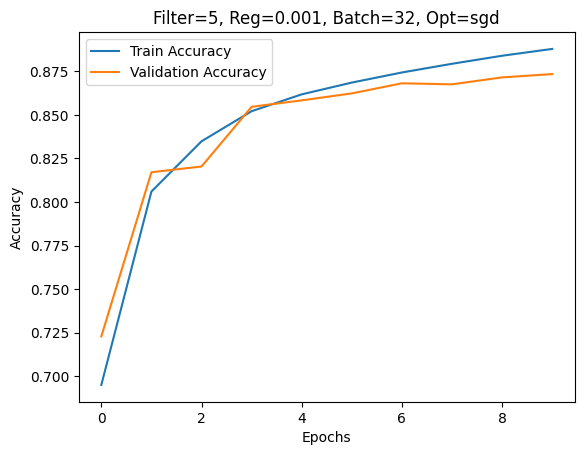

Training model with filter_size=5, reg_factor=0.001, batch_size=64, optimizer=adam
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7529 - loss: 0.8800 - val_accuracy: 0.8477 - val_loss: 0.5554
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8687 - loss: 0.4910 - val_accuracy: 0.8727 - val_loss: 0.4585
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8842 - loss: 0.4260 - val_accuracy: 0.8835 - val_loss: 0.4227
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8934 - loss: 0.3946 - val_accuracy: 0.8849 - val_loss: 0.4252
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8994 - loss: 0.3766 - val_accuracy: 0.8939 - val_loss: 0.3878
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9028 - loss: 0.3629 - val_accuracy: 0.8971 - val_loss: 0.3763
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9031 - loss: 0.3578 - val_accuracy: 0.8977 - val_loss: 0.3792
Epoch 8/10

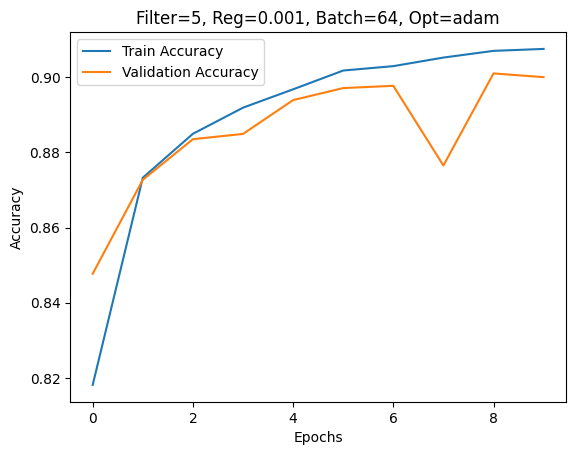

Training model with filter_size=5, reg_factor=0.001, batch_size=64, optimizer=sgd
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4908 - loss: 1.7329 - val_accuracy: 0.7264 - val_loss: 0.9880
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7668 - loss: 0.9026 - val_accuracy: 0.7977 - val_loss: 0.8229
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8056 - loss: 0.7967 - val_accuracy: 0.8202 - val_loss: 0.7633
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8269 - loss: 0.7414 - val_accuracy: 0.8177 - val_loss: 0.7533
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8421 - loss: 0.6952 - val_accuracy: 0.8397 - val_loss: 0.7072
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8485 - loss: 0.6697 - val_accuracy: 0.8455 - val_loss: 0.6701
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8595 - loss: 0.6319 - val_accuracy: 0.8551 - val_loss: 0.6453
Epoch 8/10
938/938 ━━

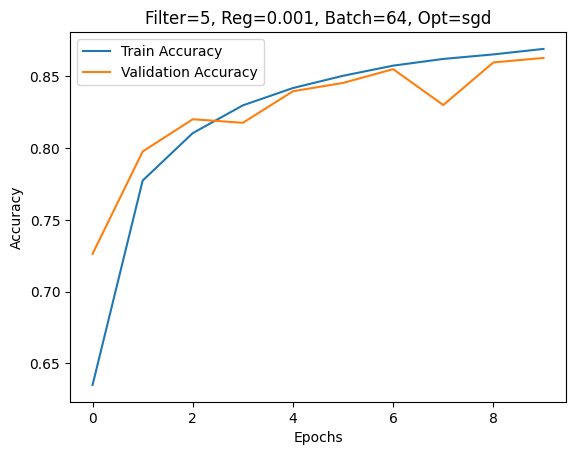

Training model with filter_size=5, reg_factor=0.0001, batch_size=32, optimizer=adam
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7691 - loss: 0.6635 - val_accuracy: 0.8642 - val_loss: 0.3984
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8819 - loss: 0.3589 - val_accuracy: 0.8848 - val_loss: 0.3588
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9019 - loss: 0.3110 - val_accuracy: 0.8927 - val_loss: 0.3359
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9107 - loss: 0.2889 - val_accuracy: 0.9007 - val_loss: 0.3198
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9182 - loss: 0.2702 - val_accuracy: 0.8930 - val_loss: 0.3324
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9243 - loss: 0.2569 - val_accuracy: 0.9044 - val_loss: 0.3195
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9297 - loss: 0.2465 - val_accuracy: 0.9049 - val_loss: 0.3248

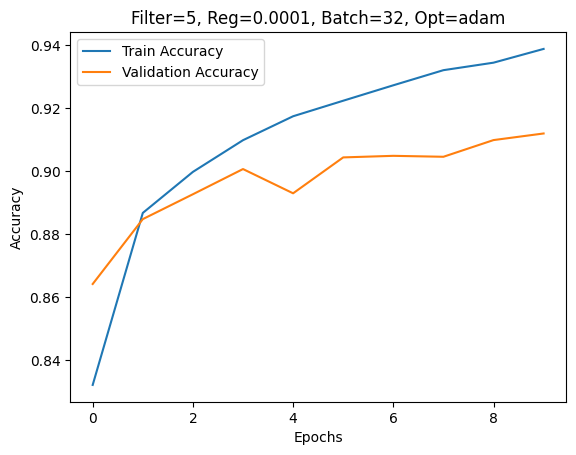

Training model with filter_size=5, reg_factor=0.0001, batch_size=32, optimizer=sgd
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5779 - loss: 1.2584 - val_accuracy: 0.7938 - val_loss: 0.6006
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8047 - loss: 0.5644 - val_accuracy: 0.8171 - val_loss: 0.5342
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8405 - loss: 0.4731 - val_accuracy: 0.8474 - val_loss: 0.4618
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8562 - loss: 0.4325 - val_accuracy: 0.8550 - val_loss: 0.4319
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8690 - loss: 0.3935 - val_accuracy: 0.8698 - val_loss: 0.3976
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8728 - loss: 0.3788 - val_accuracy: 0.8693 - val_loss: 0.3880
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8817 - loss: 0.3608 - val_accuracy: 0.8750 - val_loss: 0.3811


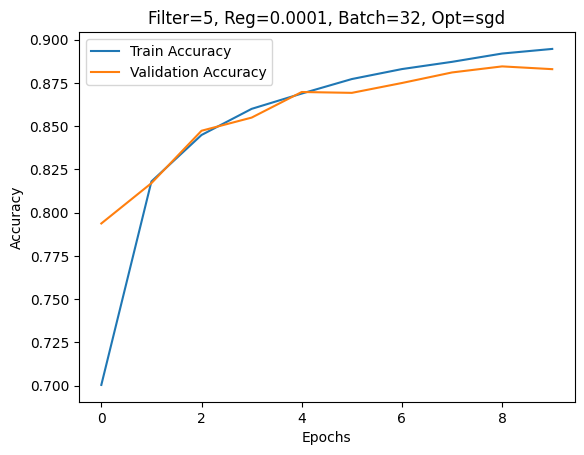

Training model with filter_size=5, reg_factor=0.0001, batch_size=64, optimizer=adam
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7508 - loss: 0.7152 - val_accuracy: 0.8693 - val_loss: 0.4018
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8813 - loss: 0.3614 - val_accuracy: 0.8768 - val_loss: 0.3698
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8977 - loss: 0.3187 - val_accuracy: 0.8858 - val_loss: 0.3513
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9084 - loss: 0.2890 - val_accuracy: 0.8867 - val_loss: 0.3378
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9147 - loss: 0.2734 - val_accuracy: 0.9009 - val_loss: 0.3197
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9228 - loss: 0.2555 - val_accuracy: 0.9071 - val_loss: 0.3068
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9284 - loss: 0.2453 - val_accuracy: 0.8983 - val_loss: 0.3287
Epoch 

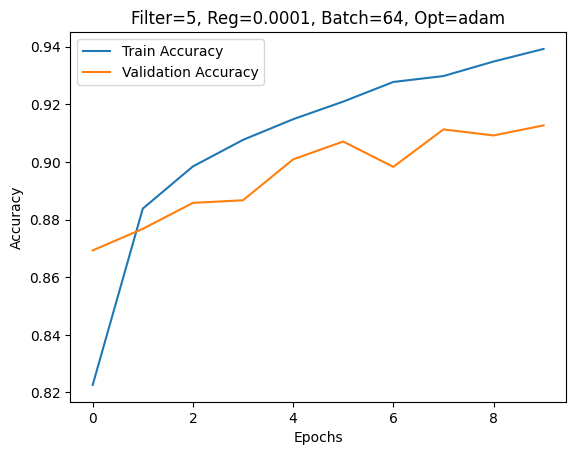

Training model with filter_size=5, reg_factor=0.0001, batch_size=64, optimizer=sgd
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5117 - loss: 1.4931 - val_accuracy: 0.7322 - val_loss: 0.7522
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.7592 - loss: 0.6716 - val_accuracy: 0.7779 - val_loss: 0.6198
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7993 - loss: 0.5772 - val_accuracy: 0.7990 - val_loss: 0.5984
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8250 - loss: 0.5164 - val_accuracy: 0.8186 - val_loss: 0.5351
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8386 - loss: 0.4752 - val_accuracy: 0.8415 - val_loss: 0.4769
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8463 - loss: 0.4571 - val_accuracy: 0.8367 - val_loss: 0.4801
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8544 - loss: 0.4322 - val_accuracy: 0.8475 - val_loss: 0.4631
Epoch 8

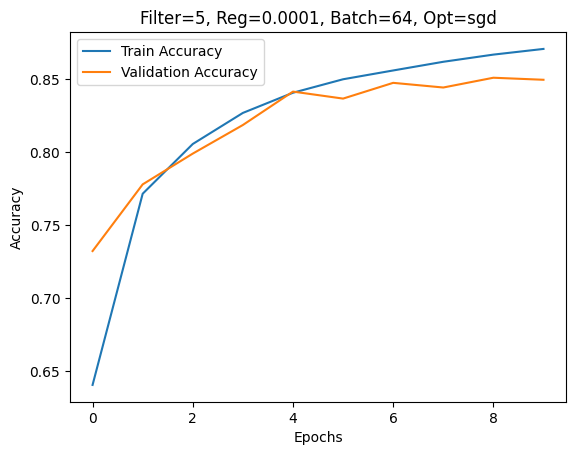

In [7]:
# Train and evaluate models
for filter_size in filter_sizes:
    for reg_factor in regularization_factors:
        for batch_size in batch_sizes:
            for optimizer in optimizers:
                print(f"Training model with filter_size={filter_size}, reg_factor={reg_factor}, batch_size={batch_size}, optimizer={optimizer}")
                model = create_model(filter_size, reg_factor, optimizer)
                history = model.fit(x_train, y_train, epochs=10, batch_size=batch_size, validation_data=(x_test, y_test), verbose=1)
                
                # Evaluate model
                test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
                print(f"Test accuracy: {test_acc:.4f}\n")
                
                # Plot training history
                plt.plot(history.history['accuracy'], label='Train Accuracy')
                plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
                plt.title(f"Filter={filter_size}, Reg={reg_factor}, Batch={batch_size}, Opt={optimizer}")
                plt.xlabel('Epochs')
                plt.ylabel('Accuracy')
                plt.legend()
                plt.show()


- Took 30 mins to run 16 combinations

# Result Markdowns